## COVID Drivers: Modeling

This notebook models POST_COVID ~ AGGRESSIVE_DRIVING

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [Logistic Regression with GridSearchCV](#lgr-gs)</BR>
* [Review Models](#review)


Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report, RocCurveDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_final.csv'

In [4]:
path_out = 'metrics_06_prim_modl_lgr.csv'

### <a id='read'>Read the data</a>

In [5]:
df_init = pd.read_csv(path_in, low_memory=False)

In [6]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [7]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [8]:
model_metrics = []

In [9]:
df.columns.tolist()

['URBAN_RURAL',
 'URBAN_RURALx',
 'POST_COVID',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'CELL_PHONE',
 'DISTRACTED']

### <a id='prep'>Preprocessing</a>

In [10]:
X = df.loc[:,['POST_COVID']].copy()

In [11]:
y = df['AGGRESSIVE_DRIVING']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### <a id='lgr-cv1'>Logistic Regression with Cross Validation</a>

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, max_iter=5000))
])

In [15]:
lgr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      max_iter=5000, random_state=42))])

In [16]:
y_pred = lgr_pipeline.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [18]:
conf_matrix = confusion_matrix(y_test, y_pred)

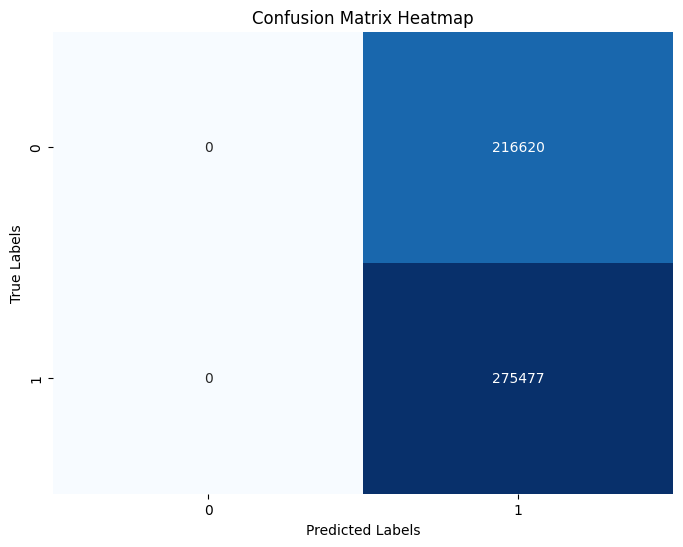

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [20]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [21]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

ROC AUC Score: 0.5030


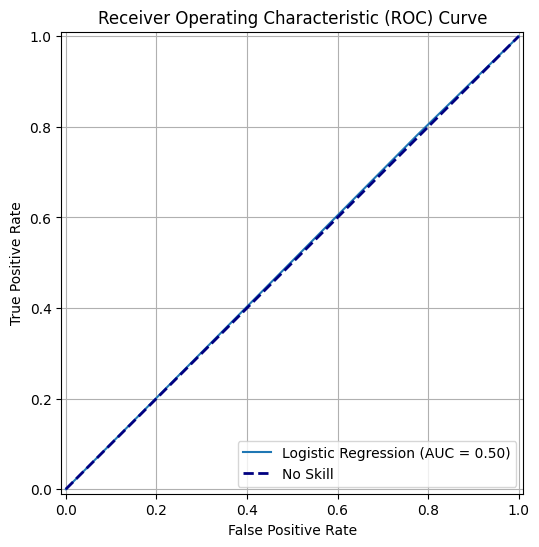

In [22]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [23]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [24]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [25]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [26]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [27]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [28]:
aggdrv_lgrcv = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [29]:
aggdrv_lgrcv['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgrcv['LogisticRegressionCV']]

In [30]:
aggdrv_lgrcv

,Measure,LogisticRegressionCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5030


In [31]:
model_metrics.append(aggdrv_lgrcv)

In [32]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### <a id='lgr-gs'>Logistic Regression with GridSearchCV</a>

In [33]:
np.logspace(-3, 3, 7)

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])

In [34]:
param_grid = {
    'logistic_regression__C': [0.01, 0.1, 1, 10, 100],
    #'logistic_regression__C': np.logspace(-3, 3, 7),
    'logistic_regression__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'logistic_regression__solver': ['saga']
    #'logistic_regression__solver': ['liblinear']
}

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegression(random_state=42, max_iter=5000))
])

In [37]:
grid_search = GridSearchCV(
    estimator=lgr_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1,
    error_score='raise'
)

In [38]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('logistic_regression',
                                        LogisticRegression(max_iter=5000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'logistic_regression__C': [0.01, 0.1, 1, 10, 100],
                         'logistic_regression__l1_ratio': [0, 0.25, 0.5, 0.75,
                                                           1],
                         'logistic_regression__solver': ['saga']},
             scoring='roc_auc', verbose=1)

In [39]:
grid_search.best_params_

{'logistic_regression__C': 0.01,
 'logistic_regression__l1_ratio': 0,
 'logistic_regression__solver': 'saga'}

In [40]:
y_pred = grid_search.predict(X_test)

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [42]:
conf_matrix = confusion_matrix(y_test, y_pred)

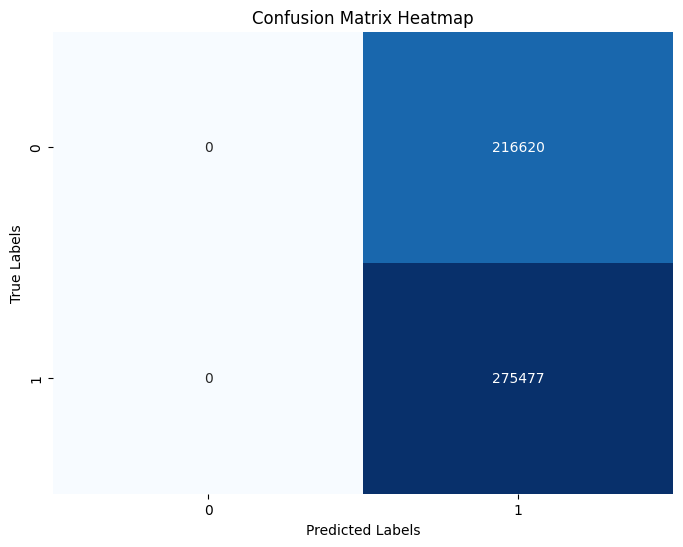

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [44]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [45]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

ROC AUC Score: 0.5030


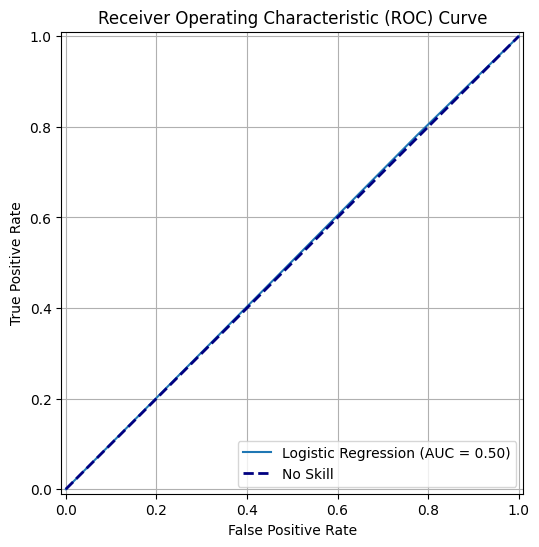

In [47]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(grid_search, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [48]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [49]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [50]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [51]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [52]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegression_GridSearchCV'

In [53]:
aggdrv_lgrgs = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [54]:
aggdrv_lgrgs['LogisticRegression_GridSearchCV'] = [round(x, 4) for x in aggdrv_lgrgs['LogisticRegression_GridSearchCV']]

In [55]:
aggdrv_lgrgs

,Measure,LogisticRegression_GridSearchCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5030


In [56]:
model_metrics.append(aggdrv_lgrgs)

In [57]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### <a id='review'>Review Models</a>

In [58]:
merged_metrics = reduce(lambda left, right: pd.merge(left, right, on='Measure', how='inner'), model_metrics)

In [59]:
merged_metrics

,Measure,LogisticRegressionCV,LogisticRegression_GridSearchCV
0,Accuracy,0.5598,0.5598
1,Precision,0.5598,0.5598
2,Recall,1.0000,1.0000
3,F1 Score,0.7178,0.7178
4,ROC AUC,0.5030,0.5030


In [60]:
merged_metrics.to_csv(path_out, index=False)